In [7]:
import uproot
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

In [8]:
branches = ['pt', 'lzr01', 'lzr02']

with uproot.open('pythia_zr_pthatmin100.root') as f:
    arr100 = f['tnR04'].arrays(branches, library='np')

with uproot.open('pythia_zr_pthatmin120.root') as f:
    arr120 = f['tnR04'].arrays(branches, library='np')

sel100 = (arr100['pt'] > 100) & (arr100['pt'] < 120)
sel120 = (arr120['pt'] > 120) & (arr120['pt'] < 140)

n100 = sel100.sum()
n120 = sel120.sum()
print(f'Selected entries: pthat100 file = {n100}, pthat120 file = {n120}')

Selected entries: pthat100 file = 10496, pthat120 file = 10448


/var/folders/k0/llmhkt1j3dx9rsgmbmwz4tvr0000gn/T/ipykernel_56415/1411786012.py:45: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


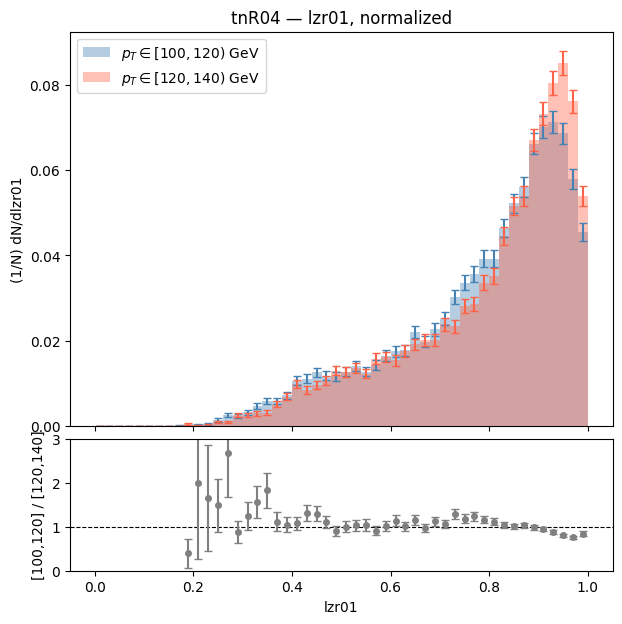

/var/folders/k0/llmhkt1j3dx9rsgmbmwz4tvr0000gn/T/ipykernel_56415/1411786012.py:45: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


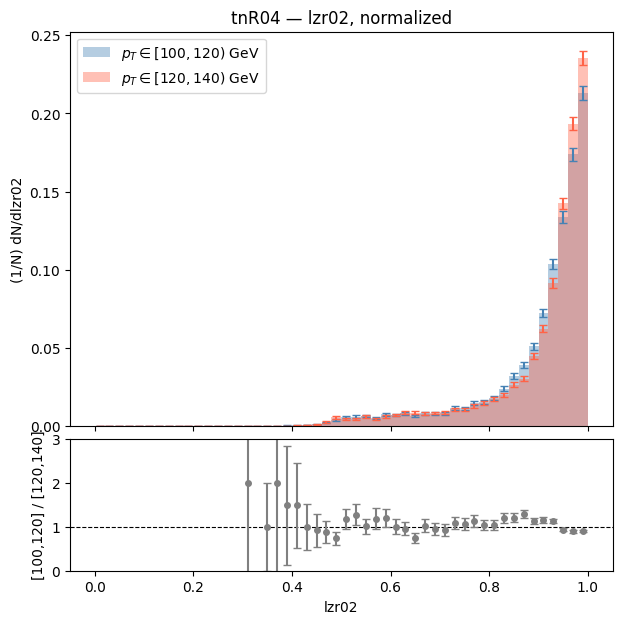

In [ ]:
bins = np.arange(0, 1.001, 0.03)

for var in ['lzr01', 'lzr02']:
    h100_raw, edges = np.histogram(arr100[var][sel100], bins=bins)
    h120_raw, _     = np.histogram(arr120[var][sel120], bins=bins)

    h100 = h100_raw.astype(float) / n100
    h120 = h120_raw.astype(float) / n120

    e100 = np.sqrt(h100_raw).astype(float) / n100
    e120 = np.sqrt(h120_raw).astype(float) / n120

    centers = 0.5 * (edges[:-1] + edges[1:])
    width   = edges[1] - edges[0]

    with np.errstate(invalid='ignore', divide='ignore'):
        ratio   = np.where(h120 > 0, h100 / h120, np.nan)
        e_ratio = np.where(
            (h100 > 0) & (h120 > 0),
            ratio * np.sqrt((e100 / np.where(h100 > 0, h100, np.nan))**2 +
                            (e120 / np.where(h120 > 0, h120, np.nan))**2),
            np.nan
        )

    fig = plt.figure(figsize=(7, 7))
    gs  = gridspec.GridSpec(2, 1, height_ratios=[3, 1], hspace=0.05)
    ax0 = fig.add_subplot(gs[0])
    ax1 = fig.add_subplot(gs[1], sharex=ax0)

    ax0.bar(centers, h100, width=width, alpha=0.4, color='steelblue', label=r'$p_T \in [100,120)$ GeV')
    ax0.errorbar(centers, h100, yerr=e100, fmt='none', ecolor='steelblue', capsize=3)
    ax0.bar(centers, h120, width=width, alpha=0.4, color='tomato', label=r'$p_T \in [120,140)$ GeV')
    ax0.errorbar(centers, h120, yerr=e120, fmt='none', ecolor='tomato', capsize=3)
    ax0.set_ylabel('(1/N) dN/d' + var)
    ax0.legend()
    ax0.set_title(f'tnR04 — {var}, normalized')
    plt.setp(ax0.get_xticklabels(), visible=False)

    ax1.axhline(1, color='k', lw=0.8, ls='--')
    ax1.errorbar(centers, ratio, yerr=e_ratio, fmt='o', color='gray', capsize=3, ms=4)
    ax1.set_ylabel('[100,120] / [120,140]')
    ax1.set_xlabel(var)
    ax1.set_ylim(0, 3)

    plt.tight_layout()
    plt.savefig(f'{var}_ratio.pdf', bbox_inches='tight')
    plt.show()

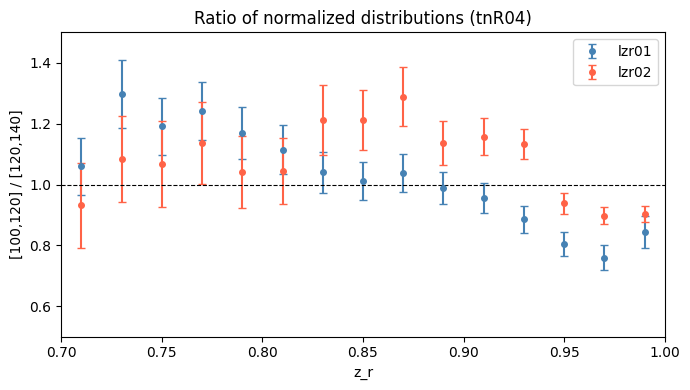

In [10]:
fig, ax = plt.subplots(figsize=(7, 4))

colors = {'lzr01': 'steelblue', 'lzr02': 'tomato'}

for var in ['lzr01', 'lzr02']:
    h100_raw, edges = np.histogram(arr100[var][sel100], bins=bins)
    h120_raw, _     = np.histogram(arr120[var][sel120], bins=bins)

    h100 = h100_raw.astype(float) / n100
    h120 = h120_raw.astype(float) / n120
    e100 = np.sqrt(h100_raw).astype(float) / n100
    e120 = np.sqrt(h120_raw).astype(float) / n120

    centers = 0.5 * (edges[:-1] + edges[1:])

    with np.errstate(invalid='ignore', divide='ignore'):
        ratio   = np.where(h120 > 0, h100 / h120, np.nan)
        e_ratio = np.where(
            (h100 > 0) & (h120 > 0),
            ratio * np.sqrt((e100 / np.where(h100 > 0, h100, np.nan))**2 +
                            (e120 / np.where(h120 > 0, h120, np.nan))**2),
            np.nan
        )

    ax.errorbar(centers, ratio, yerr=e_ratio, fmt='o', color=colors[var],
                capsize=3, ms=4, label=var)

ax.axhline(1, color='k', lw=0.8, ls='--')
ax.set_xlabel('z_r')
ax.set_ylabel('[100,120] / [120,140]')
ax.set_title('Ratio of normalized distributions (tnR04)')
ax.set_ylim(0.5, 1.5)
ax.set_xlim(0.7, 1.0)

ax.legend()
plt.tight_layout()
plt.savefig('lzr_ratio_combined.pdf', bbox_inches='tight')
plt.show()

In [ ]:
import ROOT

fout = ROOT.TFile('zr_ratios.root', 'RECREATE')

for var in ['lzr01', 'lzr02']:
    h100_raw, edges = np.histogram(arr100[var][sel100], bins=bins)
    h120_raw, _     = np.histogram(arr120[var][sel120], bins=bins)

    h100 = h100_raw.astype(float) / n100
    h120 = h120_raw.astype(float) / n120
    e100 = np.sqrt(h100_raw).astype(float) / n100
    e120 = np.sqrt(h120_raw).astype(float) / n120

    centers = 0.5 * (edges[:-1] + edges[1:])
    ex      = np.full_like(centers, 0.0)

    with np.errstate(invalid='ignore', divide='ignore'):
        ratio   = np.where(h120 > 0, h100 / h120, 0.0)
        e_ratio = np.where(
            (h100 > 0) & (h120 > 0),
            ratio * np.sqrt((e100 / np.where(h100 > 0, h100, np.nan))**2 +
                            (e120 / np.where(h120 > 0, h120, np.nan))**2),
            0.0
        )

    n = len(centers)
    g = ROOT.TGraphErrors(n,
                          centers.astype('d'), ratio.astype('d'),
                          ex.astype('d'),      e_ratio.astype('d'))
    g.SetName(f'ratio_{var}')
    g.SetTitle(f'{var} ratio [100,120)/[120,140);z_{{r}};ratio')
    g.Write()

fout.Close()
print('Saved zr_ratios.root')